<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# **Ejercicio, Encoder - Decoder**

### 1 - Datos
El objecto es utilizar una serie de sucuencias númericas (datos sintéticos) para poner a prueba el uso de las redes LSTM. Este ejemplo se inspiró en otro artículo, lo tienen como referencia en el siguiente link:\
[LINK](https://stackabuse.com/solving-sequence-problems-with-lstm-in-keras-part-2/)

In [1]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten, LSTM, SimpleRNN
from keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Input
from keras.utils import plot_model

Generamos datos sintéticos

In [2]:
X = list()
y = list()

En ambos casos "X" e "y" son vectores de números de 5 en 5

In [3]:
X = [x for x in range(5, 301, 5)]
y = [x+15 for x in X]

print(f"datos X (len={len(X)}):", X)
print(f"datos y (len={len(y)}):", y)

datos X (len=60): [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300]
datos y (len=60): [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315]


Vamos a agrupar los datos de a 3 elementos

In [4]:
X = np.array(X).reshape(len(X)//3, 3, 1)
y = np.array(y).reshape(len(y)//3, 3, 1)
print("datos X[0:2]:", X[0:2])
print("datos y[0:2]:", y[0:2])

datos X[0:2]: [[[ 5]
  [10]
  [15]]

 [[20]
  [25]
  [30]]]
datos y[0:2]: [[[20]
  [25]
  [30]]

 [[35]
  [40]
  [45]]]


Verificamos que la secuencia entrada es igual a la secuencia de salida. En cuanto a dimensiones tendremos:
* Veinte grupos de datos (rows) (20)
* Cada grupo compuesto por tres elementos (3)
* Cada elemento representado en una sola dimensión (1)

In [5]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20, 3, 1)
y shape: (20, 3, 1)


### 2 - Preprocesamiento

Importamos lo necesario

In [6]:
from sklearn import preprocessing

Armamos el "corpus" de números

In [7]:
data = np.append(X, y)

In [8]:
print(data)

[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180
 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265 270
 275 280 285 290 295 300  20  25  30  35  40  45  50  55  60  65  70  75
  80  85  90  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165
 170 175 180 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255
 260 265 270 275 280 285 290 295 300 305 310 315]


Identificamos el vocabulario del corpus (todos los números únicos)

In [9]:
labels = list(np.unique(data))

In [10]:
print(labels)

[np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(95), np.int64(100), np.int64(105), np.int64(110), np.int64(115), np.int64(120), np.int64(125), np.int64(130), np.int64(135), np.int64(140), np.int64(145), np.int64(150), np.int64(155), np.int64(160), np.int64(165), np.int64(170), np.int64(175), np.int64(180), np.int64(185), np.int64(190), np.int64(195), np.int64(200), np.int64(205), np.int64(210), np.int64(215), np.int64(220), np.int64(225), np.int64(230), np.int64(235), np.int64(240), np.int64(245), np.int64(250), np.int64(255), np.int64(260), np.int64(265), np.int64(270), np.int64(275), np.int64(280), np.int64(285), np.int64(290), np.int64(295), np.int64(300), np.int64(305), np.int64(310), np.int64(315)]


Al vocabulario (labels) le agregamos el token de inicio de secuencia. Se utiliza el número "0" para el `<sos>`, aprovechando que el "0" no se encuentra en el vocabulario. En este ejemplo todavía no vamos a usar un token especial de `<eos>` ya que siempre queremos inferir una secuencia de tamaño fijo a la salida del decoder

In [11]:
labels = [0] + labels # <sos> + vocabulario

LabelEncoder transforma el dato al token correspondiente. Ahora cada número cumple el rol de un término de un corpus y tendrá su índice asociado después de pasar por una tokenización

In [12]:
label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(labels)
label_encoder.classes_

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
       260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315])

In [13]:
print(len(label_encoder.classes_))

64


Importamos lo necesario

In [14]:
from keras.utils import to_categorical

Preparamos datos para consumir por la layers LSTM. Por cada dato de X e Y se genera su contraparte oneHotEncoding.

* X1 equivale a X, es la secuencia de entrada
* X2 es una secuencia equivalente a y pero sin el último elemento y teniendo al token <sos> como primer elemento. Es la secuencia de "estado anterior"
* target equivale a Y como OneHotEncoding, la predicción completa con el último elemento a la salida del decoder

Estamos haciendo lo siguiente:

input = [1, 2, 3]


output = [4, 5, 6]


output_in = [0, 4, 5]

In [17]:
def get_dataset(X, Y, label_encoder):

    cardinality = len(label_encoder.classes_)
    print("Cardinalidad (número de clases):", cardinality)

    X1, X2, target = list(), list(), list()
    for x, y in zip(X, Y):
        input = list(label_encoder.transform(x.reshape(-1)))
        output = list(label_encoder.transform(y.reshape(-1)))
        # Creamos la entrada del "último estado" de salida
        # que es la salida sin el último elemento, que es el que el modelo
        # debe predecir
        output_in = [0] + output[:-1]


        # transformamos
        input_encoded = to_categorical(input, num_classes=cardinality)
        output_encoded = to_categorical(output, num_classes=cardinality)
        output_in_encoded = to_categorical(output_in, num_classes=cardinality)

        # almacenamos
        X1.append(input_encoded)
        X2.append(output_in_encoded)
        target.append(output_encoded)
    return np.array(X1), np.array(X2), np.array(target)

In [18]:
X1, X2, target = get_dataset(X, y, label_encoder)

Cardinalidad (número de clases): 64


El oneHotEncoding tiene una dimensión de vocabulario + tokens_especiales:
* 63 números únicos (vocab)
* 1 token especial ( \<sos> como id=0)

El vector de salida tiene 3 dimensiones:
* primera dimensión es la cantidad de "rows" del dataset
* segunda dimensión es el tamaño de la sequencia de entrada/salida
* tercera dimensión es la dimensionalidad del vector oneHotEncoding (cardinalidad)

In [ ]:
print("X1 shape:", X1.shape)
print("X2 shape:", X2.shape)
print("target shape:", target.shape)

in_features = X1.shape[-1]
output_features = target.shape[-1]
print("Number of input_features", in_features)
print("Number of output_features", output_features)

X1 shape: (20, 3, 64)
X2 shape: (20, 3, 64)
target shape: (20, 3, 64)
Number of input_features 64
Number of output_features 64


### 3 - Entrenar el modelo

El código a continuación se puede utilizar para cualquier encoder-decoder que se desee construir con LSTM en el futuro y es posible cambiar la layer LSTM por otra (GRU, CNN, Attention, etc)

Fuente:
* https://blog.keras.io/a-ten-minute-introduction-to-sequence-to-sequence-learning-in-keras.html
* https://machinelearningmastery.com/develop-encoder-decoder-model-sequence-sequence-prediction-keras/

Importamos lo necesario

In [ ]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense

Definimos la función que define los modelos

In [ ]:
def define_models(n_input, n_output, n_units):
    '''
    Args:

        n_input: La cardinalidad de la secuencia de entrada, por ejemplo, el número de características (features), palabras o caracteres en cada paso de tiempo.
        n_output: La cardinalidad de la secuencia de salida, por ejemplo, el número de características (features), palabras o caracteres en cada paso de tiempo.
        n_units: Tamaño de las capas recurrentes utilizadas en los modelos encoder y decoder, por ejemplo, 128 o 256.

    Output:

        train: Modelo que puede ser entrenado dado la secuencia fuente, la secuencia objetivo y la secuencia objetivo desplazada (shifted target).
        inference_encoder: Modelo encoder utilizado al hacer una predicción sobre una nueva secuencia de entrada.
        inference_decoder: Modelo decoder utilizado al hacer una predicción sobre una nueva secuencia de entrada.
    '''
    # Definimos el training encoder
    encoder_inputs = Input(shape=(None, n_input))  # Entrada del encoder: secuencia de longitud variable (None) con n_input features por timestep
    encoder = LSTM(n_units, return_state=True)  # LSTM que devuelve los estados internos (hidden state y cell state)
    encoder_outputs, state_h, state_c = encoder(encoder_inputs)  # Procesa la secuencia y obtiene la salida final y los estados
    encoder_states = [state_h, state_c]  # Guardamos los estados finales del encoder (contexto)

    # Definimos el training decoder
    decoder_inputs = Input(shape=(None, n_output))  # Entrada del decoder
    decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True)  # LSTM que devuelve toda la secuencia y los estados
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
    # El decoder recibe como estado inicial los estados del encoder (contexto aprendido)

    decoder_dense = Dense(n_output, activation='softmax')  # Capa final que predice una distribución sobre el vocabulario de salida
    decoder_outputs = decoder_dense(decoder_outputs)  # Aplicamos la capa densa a cada timestep del decoder

    model = Model([encoder_inputs, decoder_inputs], decoder_outputs) # Definimos el modelo de entrenamiento









    encoder_model = Model(encoder_inputs, encoder_states) # Definimos el inference encoder, dado un input, devuelve los estados (contexto)

    # Definimos el inference decoder
    decoder_state_input_h = Input(shape=(n_units,))  # Entrada para el hidden state en inferencia
    decoder_state_input_c = Input(shape=(n_units,))  # Entrada para el cell state en inferencia
    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]  # Lista de estados de entrada

    decoder_outputs, state_h, state_c = decoder_lstm(
        decoder_inputs, initial_state=decoder_states_inputs
    )
    # En inferencia, el decoder usa estados previos en cada paso (generación paso a paso)

    decoder_states = [state_h, state_c]  # Nuevos estados generados en este timestep

    decoder_outputs = decoder_dense(decoder_outputs)
    # Convertimos la salida del LSTM en probabilidades sobre el vocabulario

    decoder_model = Model(
        [decoder_inputs] + decoder_states_inputs,  # Inputs: token actual + estados previos
        [decoder_outputs] + decoder_states         # Outputs: predicción + nuevos estados
    )
    # Modelo de inferencia del decoder: se usa iterativamente para generar la secuencia
    # Retornamos todos los modelos
    return model, encoder_model, decoder_model

Usamos la función previa para usar el modelo

In [ ]:
model, encoder_model, decoder_model = define_models(in_features, output_features, n_units=128)

model.compile(loss='categorical_crossentropy', optimizer="Adam")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 64)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None, 64)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     98,816 │ input_layer[0][0] │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │     98,816 │ input_layer_1[0]… │
│                     │ 128), (None,      │            │ lstm[0][1],       │
│                     │ 128), (None,      │            │ lstm[0][2]        │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 64)  │      8,256 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 205,888 (804.25 KB)

 Trainable params: 205,888 (804.25 KB)

 Non-trainable params: 0 (0.00 B)

Conclusiones hasta ahora sobre el modelo:
- Nunca se especificó en la layer de entrada cuantos elementos recibirá el sistema, es por eso que el modelo se creó para aceptar una cantidad dinámica de batch y size de elementos de 64 dimensiones --> None, None, 64
- El primer None corresponde al batch dinámico
- El segundo None corresponde al la cantidad de elementos dinámico

¿Cómo sabe cuantos elementos deberá esperar el sistema?
- En este caso siempre entregaremos 3 elementos al encoder y esperaremos 3 elementos del decoder.
- En un siguiente notebook de seq2seq utilizaremos tokens especiales para ello.

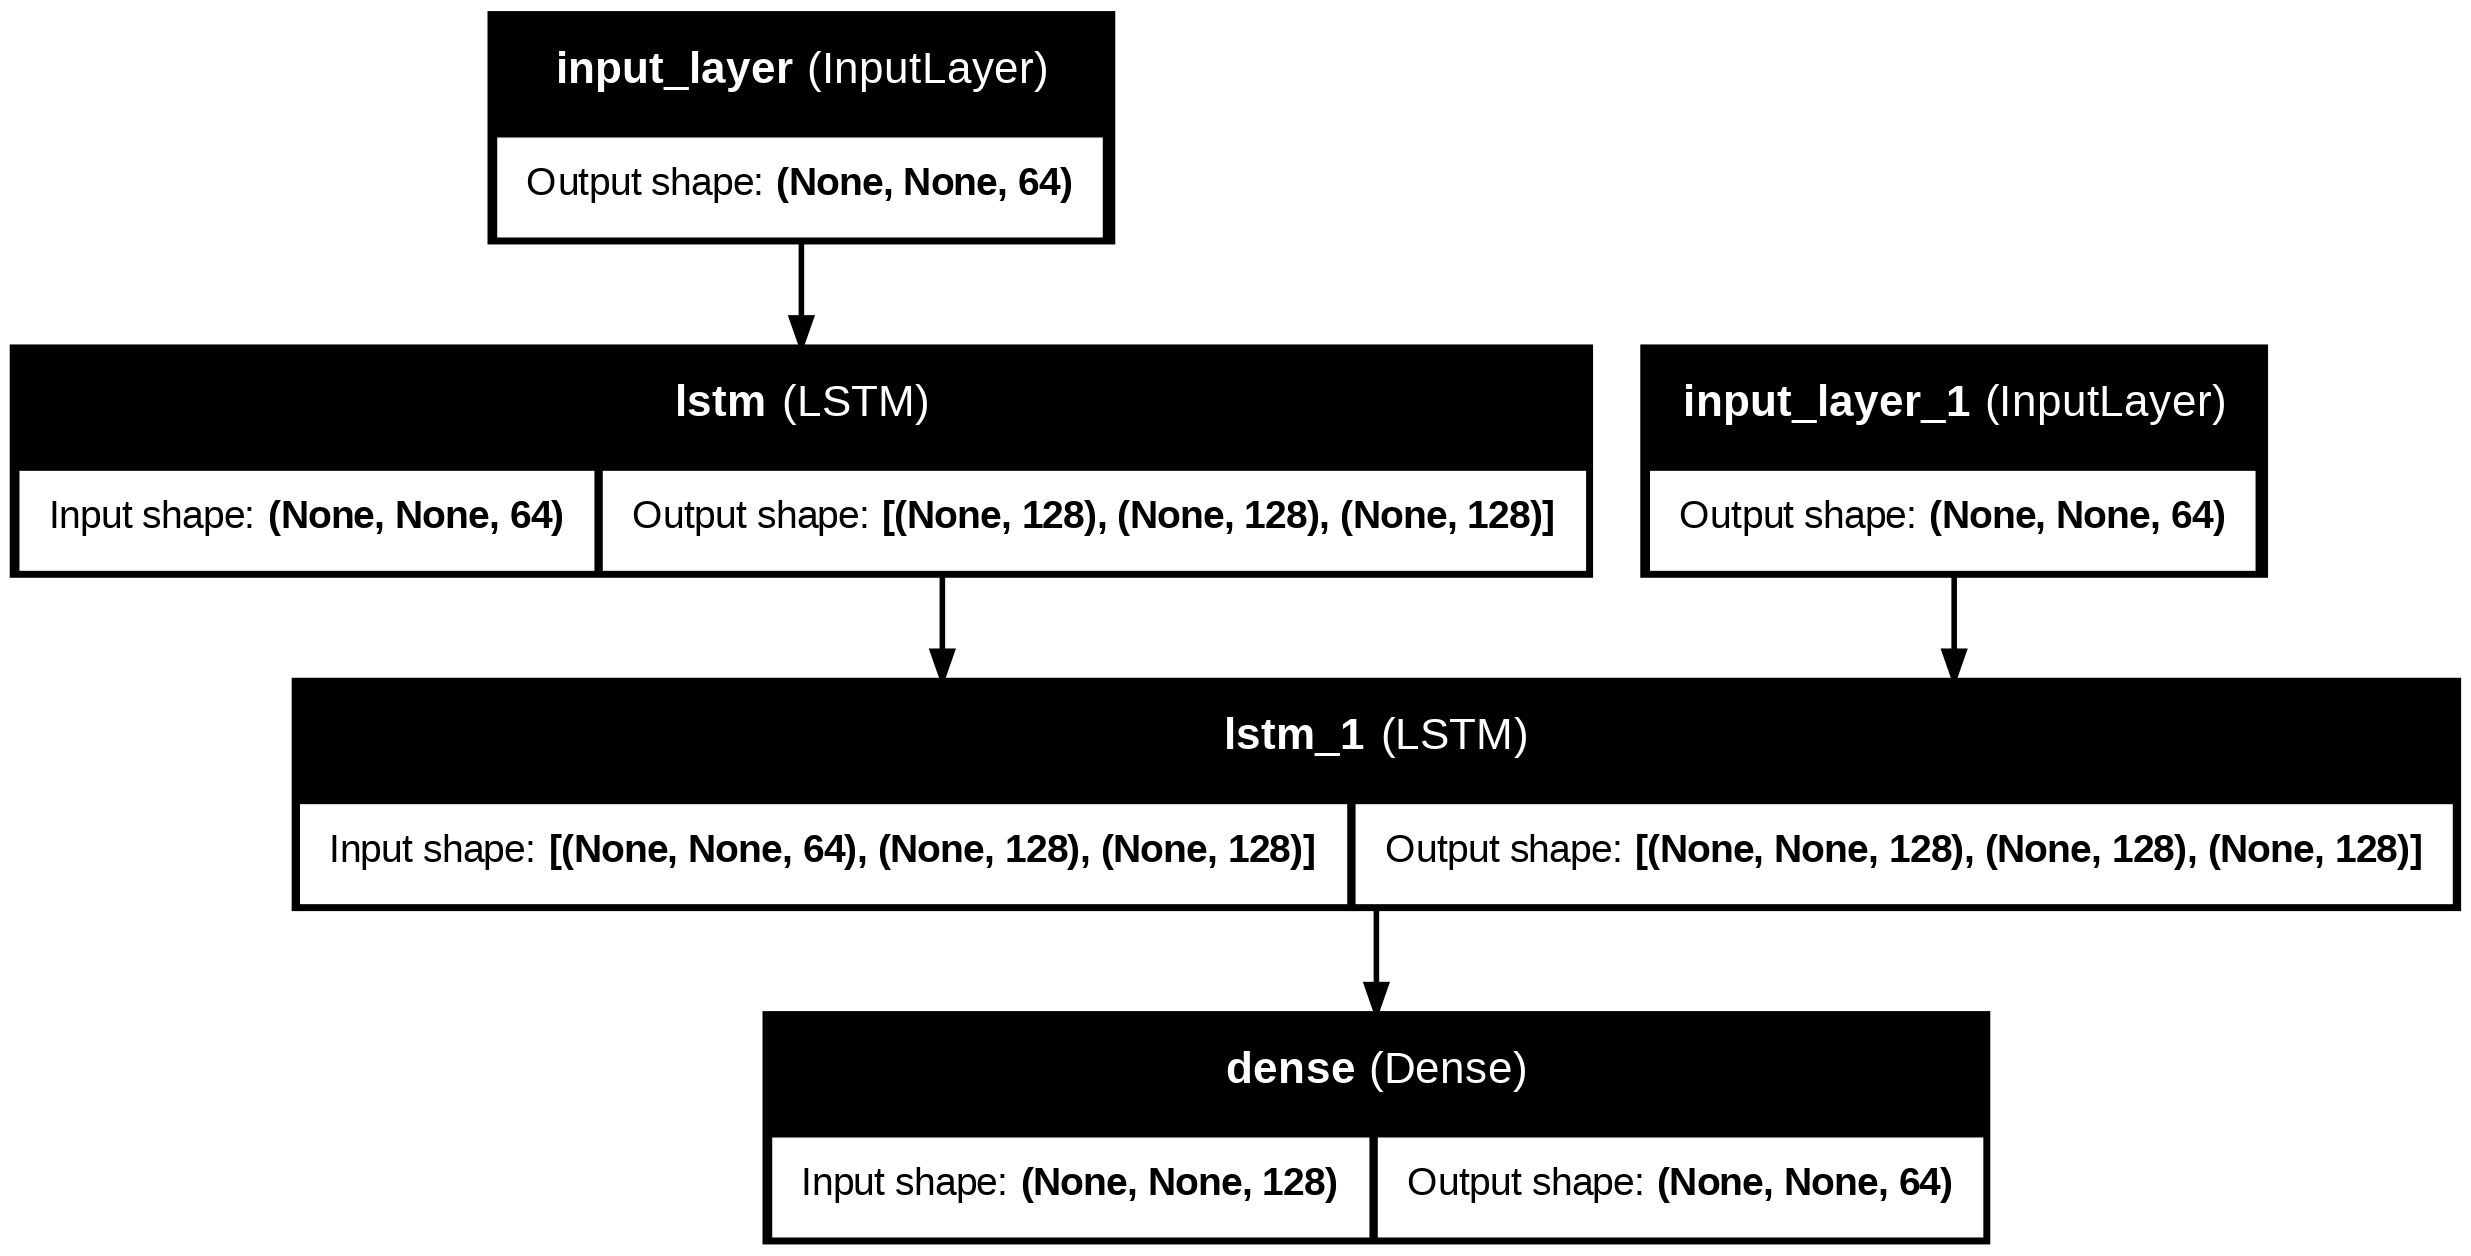

In [ ]:
# Modelo completo (encoder+decoder) para poder entrenar
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Entrenamos el modelo

In [ ]:
hist = model.fit([X1, X2], target, epochs=150, validation_split=0.2, batch_size=5)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 4.1610 - val_loss: 4.1751
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.1357 - val_loss: 4.1838
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 4.1164 - val_loss: 4.1923
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0961 - val_loss: 4.2011
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.0754 - val_loss: 4.2107
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.0550 - val_loss: 4.2212
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.0320 - val_loss: 4.2326
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.0072 - val_loss: 4.2454
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.9793 - val_loss: 4.2603
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.9483 - val_loss: 4.2784
Epoch 11/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.9116 - val_loss: 4.3007
Epoch 12/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.8705 - val_l

Visualizamos el rendimiento del modelo

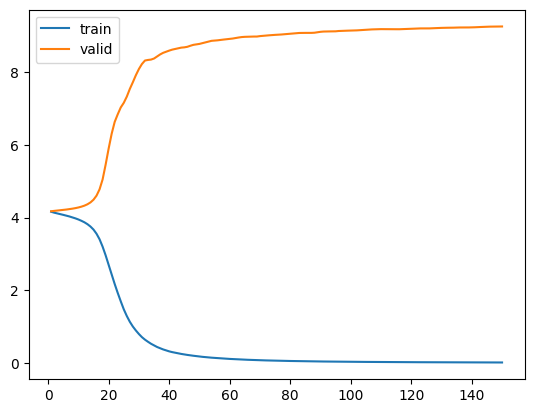

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(hist.history['loss']) + 1)
sns.lineplot(x=epoch_count,  y=hist.history['loss'], label='train')
sns.lineplot(x=epoch_count,  y=hist.history['val_loss'], label='valid')
plt.show()

La performance medida en términos de la loss empeora conforme se avanza con el entrenamiento
Esto es esperable porque en el conjunto de validación se testea sobre token que nunca se usaron en el entrenamiento.
Este análisis no tiene mucho valor para este ejemplo didáctico que se enfoca solamente en cómo construir las arquitecturas de encoder y decoder para modelos de secuencia a secuencia.

Definimos una función para pasar del índice del token al término original

In [ ]:
def one_hot_decode(encoded_seq, label_encoder):
    idx = [np.argmax(vector) for vector in encoded_seq]
    return label_encoder.inverse_transform(idx)

Definimos datos de prueba

In [ ]:
x_test = [20, 25, 30]
y_test = [x+15 for x in x_test]
print("y_test:", y_test)

y_test: [35, 40, 45]


Transformamos los datos a One Hot Encoding

In [ ]:
X1_test, X2_test, target_test = get_dataset(np.array([x_test]), np.array([y_test]), label_encoder)

print("X1_test shape:", X1_test.shape)
print("X2_test shape:", X2_test.shape)
print("target_test shape:", target_test.shape)

Cardinalidad (número de clases): 64
X1_test shape: (1, 3, 64)
X2_test shape: (1, 3, 64)
target_test shape: (1, 3, 64)


Si queremos recuperar los valores originales a partir de los valores vectorizados por OHE realizamos:

In [ ]:
one_hot_decode(target_test[0], label_encoder)

array([35, 40, 45])

Definimos la cardinalidad

In [ ]:
cardinality = len(label_encoder.classes_)

Aplicamos el **ENCODER**

Transformamos la sequencia de entrada a los estados "h" y "c" de la LSTM para enviar la primera vez al decoder

In [ ]:
state = encoder_model.predict(X1_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


La primera secuencia comienza con el ID cero

In [ ]:
output_in = to_categorical(0, num_classes=cardinality)
target_seq = np.array(output_in).reshape(1, 1, cardinality)
print("target_seq shape:", target_seq.shape)

target_seq shape: (1, 1, 64)


Definimos el vector de predicción

In [ ]:
output = list()

Empieza la parte auto-regresiva de la inferencia con el **DECODER**

In [ ]:
for t in range(3):
    # Realizamos la predicción del próximo elemento
    print("Qué recibe como elemento anterior:", one_hot_decode(target_seq[0], label_encoder))
    y_hat, h, c = decoder_model.predict([target_seq] + state)

    # Almacenamos la predicción
    output.append(y_hat[0])
    print("Qué saca como elemento nuevo o prediccion:", one_hot_decode(y_hat[0], label_encoder))
    # Actualizamos los estados dada la última prediccion
    state = [h, c]

    # Actualizamos la secuencia de entrada con la salida (re-alimentacion)
    target_seq = y_hat

print("y_test:", y_test)
print("y_hat:", one_hot_decode(output, label_encoder))

Qué recibe como elemento anterior: [0]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Qué saca como elemento nuevo o prediccion: [35]
Qué recibe como elemento anterior: [35]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Qué saca como elemento nuevo o prediccion: [40]
Qué recibe como elemento anterior: [40]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Qué saca como elemento nuevo o prediccion: [45]
y_test: [35, 40, 45]
y_hat: [35 40 45]


Podemos usar el "evaluate" de Keras pero necesitaremos de X2:

In [ ]:
model.evaluate([X1_test, X2_test], [target_test])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 0.0120


0.012043409049510956

### 4 - Conclusión
A primera vista parece muy compleja la estructura del encoder-decoder, pero funciona igual en cualquier disciplina de deeplearning:
- En visión para transferencia de estilo, generación de imagenes, etc.
- En NLP desde LSTM hasta Attention y transformers

Hay que pensar el encoder como el generador del "espacio latente". Luego el decoder necesita el espacio latente que representa a la setencia de entrada, la realimentación de los valores de salida del decoder y los estados internos de la LSTM para pasar a la siguiente inferencia hasta concluir la secuencia de salida.